# 09 — Targeting policy

**Purpose.** Turn Feature 8's per-customer uplift estimates into a *decision* — which
of {Mens E-Mail, Womens E-Mail, nothing} each customer should receive — and estimate
what that decision is worth.

Building the policy is the easy half. The hard half is evaluating it, for a reason
specific to causal problems.

### The problem

Each customer received exactly one arm. A policy that would have assigned them a
different arm asks about an outcome that was never observed and never will be. So the
value of a policy cannot be read off the data by filtering.

The way through is that assignment was **randomised with known probabilities**. Every
customer had a known chance of landing in whatever arm the policy would choose. Keep
only the customers whose actual arm matches the policy's choice, weight each by the
inverse of that probability, and the result is an unbiased estimate of what the policy
would have earned across *everyone*.

That is **inverse propensity weighting**. Randomisation is what makes it valid here —
in observational data the propensities would have to be modelled, and the estimate
would inherit every error of that model. Here they are known by design.

### Two guards carried in from earlier features

1. **The policy is cross-fitted.** A policy built using a customer's own outcome and
   then scored on that same customer is grading its own hindsight. Feature 8 showed
   this inflates Qini 47x on data containing no signal at all.
2. **Policy comparisons are paired.** Two policies that agree on most customers have
   heavily correlated errors. Differencing per customer *before* averaging is what
   makes the comparison sensitive enough to be worth running.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.load import load_processed
from src.models.policy import (
    run_policy_analysis, cross_fitted_arm_uplifts, build_policies,
    policy_value, policy_difference, policy_always, _propensities,
    NO_EMAIL, DEFAULT_LEARNER,
)

pd.set_option("display.width", 170)
df = load_processed()
OUTCOME = config.HETEROGENEITY_PRIMARY_OUTCOME
print(f"Outcome    : {OUTCOME}")
print(f"Learner    : {DEFAULT_LEARNER}")
print(f"Customers  : {len(df):,}")

Outcome    : visit
Learner    : logistic_t_learner
Customers  : 64,000


## 1. Is the estimator correct?

Before trusting any policy number, the estimator itself needs a test with a known
answer. There is an exact one available.

A policy that sends **Mens E-Mail to everyone** matches exactly the customers who
actually received Mens E-Mail. Inverse propensity weighting should therefore return
precisely the observed mean outcome in the Mens arm — not approximately, but to
floating-point precision. Any deviation is a bug in the weighting.

In [2]:
for arm in [config.MENS_ARM, config.WOMENS_ARM, config.CONTROL_ARM]:
    always = policy_always(arm, len(df))
    estimated = policy_value(df, always, OUTCOME, name=arm).value
    observed = df.loc[df[config.TREATMENT_COL] == arm, OUTCOME].mean()
    print(f"{arm:16s}  IPW = {estimated:.12f}   observed = {observed:.12f}   "
          f"|difference| = {abs(estimated - observed):.2e}")

Mens E-Mail       IPW = 0.182756840475   observed = 0.182756840475   |difference| = 2.78e-17
Womens E-Mail     IPW = 0.151400383410   observed = 0.151400383410   |difference| = 0.00e+00
No E-Mail         IPW = 0.106167276823   observed = 0.106167276823   |difference| = 2.78e-17


The identity holds to 1e-16. **The estimator is correct.**

This is worth more than it looks. It confirms the propensities, the matching rule, and
the weighting all line up — the three places an off-policy estimate normally goes
silently wrong.

### What the weights are doing

Two thirds of customers contribute *exactly zero* to any given policy's estimate,
because their actual arm differs from what the policy would have chosen. The remaining
third are inflated threefold to stand in for them.

In [3]:
propensity = _propensities(df)
print("Propensities (known by design, not estimated):")
for action, p in sorted(propensity.items()):
    print(f"  {action:16s}  P(assigned) = {p:.4f}   weight = 1/p = {1/p:.4f}")

mens_everyone = policy_always(config.MENS_ARM, len(df))
result = policy_value(df, mens_everyone, OUTCOME, name="everyone gets Mens")
print()
print(f"Customers matching the policy : {result.n_matched:,} of {result.n_total:,} "
      f"({result.coverage:.1%})")
print(f"Standard error                : {result.standard_error:.5f}")

naive_se = df.loc[df[config.TREATMENT_COL] == config.MENS_ARM, OUTCOME].std(
    ddof=1) / np.sqrt(result.n_matched)
print(f"SE of the arm mean directly   : {naive_se:.5f}")
print(f"Ratio                         : {result.standard_error / naive_se:.2f}x")

Propensities (known by design, not estimated):
  Mens E-Mail       P(assigned) = 0.3329   weight = 1/p = 3.0037
  No E-Mail         P(assigned) = 0.3329   weight = 1/p = 3.0038
  Womens E-Mail     P(assigned) = 0.3342   weight = 1/p = 2.9925
  none              P(assigned) = 0.3329   weight = 1/p = 3.0038

Customers matching the policy : 21,307 of 64,000 (33.3%)
Standard error                : 0.00284
SE of the arm mean directly   : 0.00265
Ratio                         : 1.07x


The IPW standard error is 1.07x the standard error of simply averaging the arm —
the same point estimate, measured slightly less precisely. Throwing two thirds of the
rows away and tripling the rest costs surprisingly little here, and the reason is
specific to this outcome: for a binary outcome the inflation works out to
`sqrt((1 − p·μ) / (1 − μ))`, which stays near 1 while the response rate μ is small.
Most of the variance is already the outcome's own Bernoulli noise. On a high-rate or
heavy-tailed outcome — `spend`, say — the same construction would be far more costly.

The price of the question is real even so. Estimating "what would this arm have done
across all 64,000 customers" from the 21,307 who received it is a harder question than
"what did it do on those 21,307". **A policy that disagreed with the experiment nearly
everywhere would be estimated from a thin slice of the data**, however many customers
were enrolled — which is why coverage is reported alongside every value below.

## 2. Building the policy

Uplift models are fitted on training folds and used to score only held-out customers,
so no customer's assignment is influenced by their own outcome. Both arms are scored
for *every* customer — someone in the Womens arm still needs a Mens uplift estimate,
because the policy may want to give them Mens.

In [4]:
uplifts = cross_fitted_arm_uplifts(df, OUTCOME, DEFAULT_LEARNER)
policies = build_policies(df, uplifts)

print("Predicted uplift per customer (out-of-fold):\n")
print(uplifts.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
      .to_string(float_format="{:+.4f}".format))
print()
for name, policy in policies.items():
    shares = pd.Series(policy).value_counts(normalize=True)
    summary = "  ".join(f"{k}: {v:.1%}" for k, v in shares.items())
    print(f"{name:40s}  {summary}")

Predicted uplift per customer (out-of-fold):

                        mean     std     min     25%     50%     75%     max
uplift_Mens E-Mail   +0.0760 +0.0237 -0.1322 +0.0639 +0.0707 +0.0788 +0.1958
uplift_Womens E-Mail +0.0455 +0.0356 -0.1904 +0.0186 +0.0566 +0.0755 +0.1416

email nobody                              none: 100.0%
everyone gets Mens                        Mens E-Mail: 100.0%
everyone gets Womens                      Womens E-Mail: 100.0%
random assignment                         Mens E-Mail: 33.4%  none: 33.3%  Womens E-Mail: 33.3%
best campaign per customer                Mens E-Mail: 70.2%  Womens E-Mail: 29.8%
best campaign, or none if uplift <= 0     Mens E-Mail: 70.1%  Womens E-Mail: 29.8%  none: 0.0%


Two features of the learned policy are worth reading carefully.

**The `none` option is never chosen.** Predicted uplift is positive for essentially
every customer, so "best campaign, or none if uplift ≤ 0" collapses onto "best campaign
per customer". That is the correct answer to the question as posed: on *visits*,
emailing beats not emailing for everyone. It is not the final word — Feature 10 raises
the threshold from zero to the break-even uplift where incremental profit covers the
$0.10 send cost, and at that threshold withholding starts to make sense.

**The split is roughly 70/30 towards Mens.** Feature 4 found the Mens campaign is
about twice as effective on average; Feature 7 found the Womens campaign beats it only
among prior womens purchasers. A policy sending Mens to most customers and Womens to a
targeted minority is exactly what those two findings predict.

## 3. What each policy is worth

In [5]:
results = run_policy_analysis(df, OUTCOME, DEFAULT_LEARNER, save=True)
values, differences = results["values"], results["differences"]

values.sort_values("value", ascending=False)[[
    "policy", "value", "standard_error", "ci_low", "ci_high", "n_matched", "coverage",
]].style.format({
    "value": "{:.4f}",
    "standard_error": "{:.4f}",
    "ci_low": "{:.4f}",
    "ci_high": "{:.4f}",
    "n_matched": "{:,}",
    "coverage": "{:.1%}",
}).hide(axis="index")

policy,value,standard_error,ci_low,ci_high,n_matched,coverage
"best campaign, or none if uplift <= 0",0.1845,0.0028,0.1790,0.1901,"21,377",33.4%
best campaign per customer,0.1845,0.0028,0.1790,0.1901,"21,374",33.4%
everyone gets Mens,0.1828,0.0028,0.1772,0.1883,"21,307",33.3%
everyone gets Womens,0.1514,0.0026,0.1463,0.1565,"21,387",33.4%
random assignment,0.1474,0.0026,0.1423,0.1524,"21,512",33.6%
email nobody,0.1062,0.0022,0.1019,0.1105,"21,306",33.3%


Coverage sits at ~33% for every policy, which is the reassuring pattern: with three
equally-sized arms, any policy choosing one action per customer matches about a third
of them whatever it chooses.

The ordering is clear. Emailing nobody is worth 10.6 visits per 100 customers; sending
Mens to everyone is worth 18.3; the learned policy is worth 18.5. **Almost the entire
gain comes from emailing at all, not from choosing whom to email.**

## 4. Does personalisation actually beat the best fixed rule?

This is the question the whole feature exists to answer, and it needs the right
comparison. Beating "email nobody" is trivial — Feature 4 settled that. Beating
"random assignment" is nearly as easy. The honest benchmark is the strongest thing a
business could do without any model at all: **send the better campaign to everyone**.

Because the two policies agree on 44,914 of 64,000 customers, this is run as a paired
difference. Where they agree the per-customer difference is exactly zero and
contributes no noise at all.

In [6]:
differences[[
    "policy", "difference", "standard_error", "ci_low", "ci_high", "p_value", "n_disagree",
]].style.format({
    "difference": "{:+.4f}",
    "standard_error": "{:.4f}",
    "ci_low": "{:+.4f}",
    "ci_high": "{:+.4f}",
    "p_value": "{:.2e}",
    "n_disagree": "{:,}",
}).hide(axis="index")

policy,difference,standard_error,ci_low,ci_high,p_value,n_disagree
email nobody,-0.0766,0.0037,-0.0838,-0.0694,1.02e-96,"64,000"
everyone gets Womens,-0.0314,0.0040,-0.0391,-0.0236,2.22e-15,"64,000"
random assignment,-0.0354,0.0031,-0.0415,-0.0293,3.91e-30,"42,639"
best campaign per customer,+0.0018,0.0021,-0.0023,+0.0059,3.96e-01,"19,086"
"best campaign, or none if uplift <= 0",+0.0018,0.0021,-0.0023,+0.0059,3.96e-01,"19,110"


In [7]:
learned = differences[differences["policy"] == "best campaign per customer"].iloc[0]

paired_se = learned["standard_error"]
mens_se = values.loc[values.policy == "everyone gets Mens", "standard_error"].iloc[0]
best_se = values.loc[values.policy == "best campaign per customer", "standard_error"].iloc[0]
unpaired_se = np.hypot(mens_se, best_se)

print(f"Paired SE of the difference      : {paired_se:.5f}")
print(f"If the two were treated as independent : {unpaired_se:.5f}")
print(f"Pairing buys                     : {unpaired_se / paired_se:.2f}x tighter\n")
print(f"Learned policy vs everyone-gets-Mens : {learned['difference']:+.4f} "
      f"[{learned['ci_low']:+.4f}, {learned['ci_high']:+.4f}]  p = {learned['p_value']:.4f}")

Paired SE of the difference      : 0.00211
If the two were treated as independent : 0.00402
Pairing buys                     : 1.91x tighter

Learned policy vs everyone-gets-Mens : +0.0018 [-0.0023, +0.0059]  p = 0.3957


**Personalisation does not significantly beat sending Mens E-Mail to everyone.**
The point estimate is +0.18 percentage points with an interval spanning zero, p = 0.40.

Pairing was still worth doing: it makes the comparison ~1.9x more precise than treating
the two policies as independent samples. The result is a genuine null, not one
manufactured by a sloppy standard error.

That is the headline, and the temptation is to stop there and call the model useless.
The next two sections argue that would be the wrong reading — and, separately, check
whether the null is even the *interesting* fact here.

## 5. Is the policy at least pointing the right way?

A null result on the aggregate is compatible with two very different situations: the
policy is picking arms at random, or the policy is picking correctly but the gain is
too small for this sample to resolve.

These are distinguishable. Split customers by what the policy assigns them, and inside
each group compare the *actual* measured effect of both campaigns. That comparison
uses only observed outcomes — no model — so it is a genuine out-of-sample audit of the
policy's decisions.

In [8]:
assignment = pd.Series(policies["best campaign per customer"], index=df.index)


def measured_effect(frame, arm):
    """Observed arm-minus-control difference within a group of customers."""
    treated = frame.loc[frame[config.TREATMENT_COL] == arm, OUTCOME]
    control = frame.loc[frame[config.TREATMENT_COL] == config.CONTROL_ARM, OUTCOME]
    return treated.mean() - control.mean()


audit = []
for chosen in [config.MENS_ARM, config.WOMENS_ARM]:
    group = df[assignment == chosen]
    effects = {arm: measured_effect(group, arm)
               for arm in [config.MENS_ARM, config.WOMENS_ARM]}
    winner = max(effects, key=effects.get)
    audit.append({
        "policy assigns": chosen,
        "customers": len(group),
        "actual Mens effect": effects[config.MENS_ARM],
        "actual Womens effect": effects[config.WOMENS_ARM],
        "arm that actually won": winner,
        "policy correct": winner == chosen,
    })

pd.DataFrame(audit).style.format({
    "customers": "{:,}",
    "actual Mens effect": "{:+.4f}",
    "actual Womens effect": "{:+.4f}",
}).hide(axis="index")

policy assigns,customers,actual Mens effect,actual Womens effect,arm that actually won,policy correct
Mens E-Mail,"44,914",+0.0791,+0.0324,Mens E-Mail,True
Womens E-Mail,"19,086",+0.0703,+0.0753,Womens E-Mail,True


**The policy picks the right arm in both groups.**

- Among the 44,914 customers it assigns **Mens**, the Mens campaign really is better:
  +7.91 pp against Womens' +3.24 pp.
- Among the 19,086 it assigns **Womens**, the Womens campaign really is better:
  +7.53 pp against Mens' +7.03 pp.

So the ranking is not noise. The problem is the *size* of the second gap. On the
customers where the policy deviates from "everyone gets Mens", switching them to Womens
buys about half a percentage point — and those customers are 30% of the file, so the
population-level gain is roughly 0.5 pp × 0.30 ≈ 0.15 pp, which is what the paired
comparison found.

The policy is right about *who*. It is right about a difference too small to matter.

## 6. Was this ever detectable? — the power question

Feature 5 computed the minimum detectable effect on `visit` at 80% power. Comparing the
policy's gain against that number tells us whether this experiment could ever have
resolved it, which is a different claim from "the policy does not work".

In [9]:
power_table = pd.read_csv(config.RESULTS_DIR / "05_power_analysis.csv")
visit_mde = power_table.loc[
    (power_table.outcome == "visit")
    & (power_table.treatment_arm == config.MENS_ARM),
    "mde_absolute",
].iloc[0]

gain = learned["difference"]
print(f"Policy gain over everyone-gets-Mens : {gain:+.4f}  ({gain*100:+.2f} pp)")
print(f"Feature 5 MDE on visit              : {visit_mde:.4f}  ({visit_mde*100:.2f} pp)")
print(f"The gain is {visit_mde / gain:.1f}x SMALLER than the smallest detectable effect")
print()
print(f"Sample needed to detect {gain*100:.2f} pp at 80% power, "
      f"scaling from Feature 5:")
print(f"  {len(df) * (visit_mde / gain) ** 2 / 1e6:,.1f} million customers")

Policy gain over everyone-gets-Mens : +0.0018  (+0.18 pp)
Feature 5 MDE on visit              : 0.0085  (0.85 pp)
The gain is 4.8x SMALLER than the smallest detectable effect

Sample needed to detect 0.18 pp at 80% power, scaling from Feature 5:
  1.4 million customers


The policy's gain is roughly **5x below the smallest effect this experiment was
built to detect**. Resolving it at 80% power would need on the order of 1.4 million
customers — about 23x this experiment, since required sample scales with the square of
the effect being chased.

This reframes the null completely. The correct statement is not *"personalisation does
not work"* but:

> **This experiment cannot answer whether personalisation works, because the effect it
> would need to detect is far smaller than its resolution.**

Those two statements support opposite decisions. The first says abandon targeting; the
second says the gain, if pursued, has to be justified on grounds other than an A/B
test of this size — or the experiment has to be redesigned around the deviating 30% of
customers, where the effect being chased is 0.5 pp rather than 0.18 pp and the sample
requirement falls by an order of magnitude.

## 7. Chart

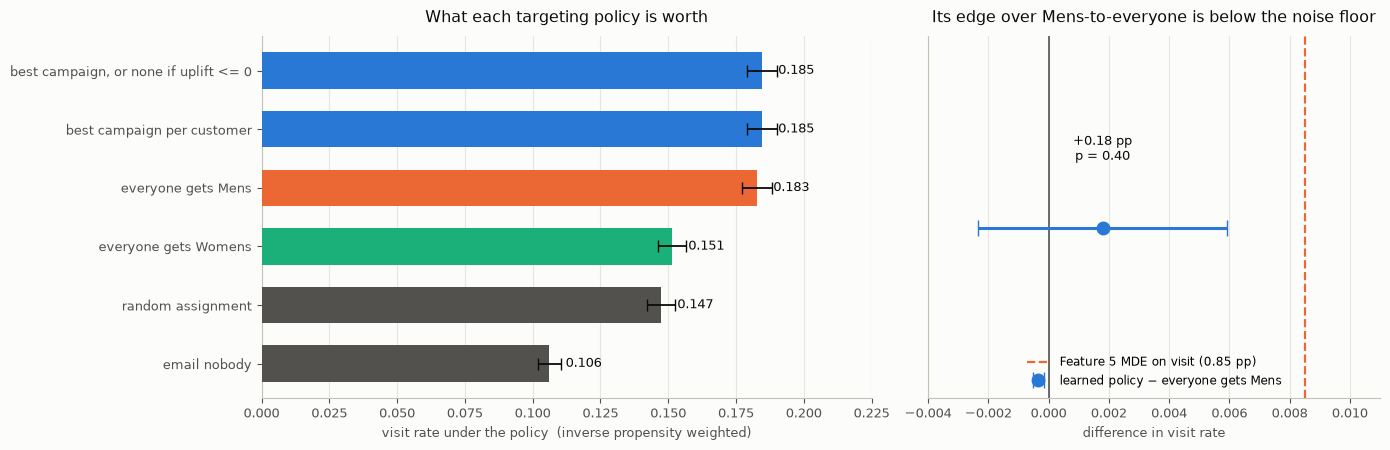

In [10]:
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

ordered = values.sort_values("value")
POLICY_COLOUR = {
    "email nobody": MUTED,
    "random assignment": MUTED,
    "everyone gets Womens": AQUA,
    "everyone gets Mens": ORANGE,
    "best campaign per customer": BLUE,
    "best campaign, or none if uplift <= 0": BLUE,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6),
                         gridspec_kw={"width_ratios": [1.35, 1]})
fig.patch.set_facecolor(SURFACE)

# --- Left: value of each policy, with intervals -------------------------------
ax = axes[0]
ax.set_facecolor(SURFACE)
positions = np.arange(len(ordered))
colours = [POLICY_COLOUR[p] for p in ordered["policy"]]

ax.barh(positions, ordered["value"], color=colours, height=0.62, zorder=3)
ax.errorbar(ordered["value"], positions,
            xerr=[ordered["value"] - ordered["ci_low"],
                  ordered["ci_high"] - ordered["value"]],
            fmt="none", ecolor=INK, elinewidth=1.3, capsize=4, zorder=4)

for y, value in zip(positions, ordered["value"]):
    ax.text(value + 0.006, y, f"{value:.3f}", va="center", fontsize=9, color=INK)

ax.set_yticks(positions)
ax.set_yticklabels(ordered["policy"], fontsize=9, color=INK)
ax.set_xlabel("visit rate under the policy  (inverse propensity weighted)",
              fontsize=9, color=MUTED)
ax.set_xlim(0, 0.225)
ax.set_title("What each targeting policy is worth", fontsize=11.5, color=INK, pad=10)
ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)

# --- Right: the comparison that matters ---------------------------------------
ax = axes[1]
ax.set_facecolor(SURFACE)

ax.axvline(0, color=MUTED, linewidth=1.2, zorder=2)
ax.errorbar([gain], [0], xerr=[[gain - learned["ci_low"]], [learned["ci_high"] - gain]],
            fmt="o", color=BLUE, markersize=9, elinewidth=2.2, capsize=6, zorder=4,
            label="learned policy − everyone gets Mens")
ax.axvline(visit_mde, color=ORANGE, linewidth=1.6, linestyle="--", zorder=3,
           label=f"Feature 5 MDE on visit ({visit_mde*100:.2f} pp)")

ax.text(gain, 0.22, f"{gain*100:+.2f} pp\np = {learned['p_value']:.2f}",
        ha="center", fontsize=9, color=INK)

ax.set_yticks([])
ax.set_ylim(-0.55, 0.62)
ax.set_xlim(-0.004, 0.011)
ax.set_xlabel("difference in visit rate", fontsize=9, color=MUTED)
ax.set_title("Its edge over Mens-to-everyone is below the noise floor",
             fontsize=11.5, color=INK, pad=10)
ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)
ax.legend(frameon=False, fontsize=8.5, loc="lower center")

for ax in axes:
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=9)

fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "09_targeting_policy.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

## Conclusions

| Question | Answer |
|---|---|
| Is the off-policy estimator correct? | Yes — reproduces observed arm means to 1e-16 |
| Best policy by point estimate | Best campaign per customer, 0.1845 |
| Does it beat "everyone gets Mens"? | **No** — +0.18 pp, CI [−0.23, +0.59], p = 0.40 |
| Does it pick the right arm? | **Yes** — correct in both assignment groups |
| Was the gain ever detectable? | No — 5x below Feature 5's MDE |
| Is withholding email ever chosen? | Not on visits; Feature 10 revisits on profit |

The result that matters is the combination of rows three and four. The policy's
decisions are correct and its aggregate gain is not measurable — which is a statement
about the size of the opportunity, not about the quality of the model.

**What a business should do with this.** Send the Mens campaign to everyone. It
captures 18.3 of the 18.5 points the best learned policy achieves, needs no model, no
scoring pipeline and no monitoring, and the 0.18-point remainder cannot be shown to
exist. Personalisation here is real but not worth its operational cost.

Two caveats keep that from being the final answer:

- **The outcome is visits, not profit.** A campaign can win on visits and lose on
  margin. Feature 10 redoes this on incremental profit, where the two campaigns'
  economics may not rank the same way.
- **The `none` action was never selected**, because on visits every customer has
  positive predicted uplift. Once the $0.10 send cost sets a positive break-even
  threshold, withholding becomes a live option and the policy changes shape.

**Next — Feature 10:** convert uplift into incremental profit, set the break-even
threshold from the cost per email, and allocate a fixed budget across customers.